# Pair-level AlphaFold Metrics: ipTM, pLDDT, PAE

Reads every dimer pair inside a `pairs/` directory and computes:

| Metric | Source | Granularity |
|--------|--------|-------------|
| **pLDDT** | PDB B-factor (Cα) | per-residue list |
| **PAE** | `*_confidences.json` → `pae` matrix | per-residue row-mean |
| **ipTM** | derived from inter-chain PAE (TM-score formula, interface = PAE < 12 Å) | one scalar per pair |

The interface-based ipTM formula:

$$\text{ipTM} = \frac{1}{|\mathcal{I}|} \sum_{(i,j)\in\mathcal{I}} \frac{1}{1 + (\text{PAE}_{ij}/d_0)^2}, \quad d_0 = 1.24(N-15)^{1/3} - 1.8$$

where $\mathcal{I}$ are inter-chain pairs for which PAE$_{ij}$ < 12 Å or PAE$_{ji}$ < 12 Å.

In [23]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from Bio.PDB import PDBParser
import warnings
warnings.filterwarnings('ignore')

In [24]:
# ── Configuration ────────────────────────────────────────────────────────────
pairdir = Path(r"N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex\pairs")

# chains.csv lives one level above pairs/ (i.e. inside assembled_complex/)
chains_csv = pairdir.parent / "chains.csv"

USE_ALL_MODELS       = False
INTERFACE_PAE_CUTOFF = 12.0

# Publication-quality SVG output directory
FIGURE_DIR = (
    Path(r"N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result")
    / "metrics_figures"
)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Figure output → {FIGURE_DIR}")

Figure output → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\metrics_figures


In [ ]:
# ── Nature figure style ───────────────────────────────────────────────────────
import matplotlib as mpl

mpl.rcParams.update({
    # Font
    "font.family":        "sans-serif",
    "font.sans-serif":    ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size":          7,
    "axes.titlesize":     8,
    "axes.labelsize":     7,
    "xtick.labelsize":    6,
    "ytick.labelsize":    6,
    "legend.fontsize":    6,
    "legend.title_fontsize": 6,
    "legend.frameon":     False,
    "legend.borderpad":   0.3,
    # Axes / ticks
    "axes.linewidth":     0.5,
    "xtick.major.width":  0.5,
    "ytick.major.width":  0.5,
    "xtick.major.size":   2.5,
    "ytick.major.size":   2.5,
    "xtick.direction":    "out",
    "ytick.direction":    "out",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    # Lines / patches
    "lines.linewidth":    0.75,
    "patch.linewidth":    0.5,
    # Save
    "figure.dpi":         300,
    "savefig.dpi":        300,
    "savefig.bbox":       "tight",
    "savefig.pad_inches": 0.05,
    "pdf.fonttype":       42,   # embed fonts as outlines
    "ps.fonttype":        42,
})

# Nature column widths in inches (mm → inch)
NC1 = 89  / 25.4   # single column ≈ 3.50"
NC2 = 183 / 25.4   # double column ≈ 7.20"

# Wong (2011) colour-blind-safe palette
WONG = ["#0072B2", "#E69F00", "#009E73", "#CC79A7",
        "#56B4E9", "#D55E00", "#F0E442", "#000000"]

# Lower-case panel labels: a–z for idx 0–25, aa–az for 26–51, etc.
def _panel_label(idx):
    q, r = divmod(idx, 26)
    base = chr(ord('a') + r)
    return (chr(ord('a') + q - 1) + base) if q else base


def save_fig(fig, name):
    """Save *fig* as SVG to FIGURE_DIR and print the path."""
    path = FIGURE_DIR / f"{name}.svg"
    fig.savefig(path, format="svg")
    print(f"Saved → {path}")

In [26]:
# ── Helper functions ─────────────────────────────────────────────────────────

_pdb_parser = PDBParser(QUIET=True)


def get_ca_plddt(pdb_path):
    """Return per-residue pLDDT (Cα B-factor), chain IDs, and residue numbers."""
    structure = _pdb_parser.get_structure("s", str(pdb_path))
    plddt, chains, res_ids = [], [], []
    for model in structure:
        for chain in model:
            for res in chain:
                if res.id[0] != " ":
                    continue
                if "CA" not in res:
                    continue
                ca = res["CA"]
                plddt.append(ca.get_bfactor())
                chains.append(chain.id)
                res_ids.append(res.id[1])
    return np.array(plddt), np.array(chains), np.array(res_ids, dtype=int)


def compute_iptm(pae, token_chain_ids, interface_cutoff=INTERFACE_PAE_CUTOFF):
    """
    Compute interface-TM score from a PAE matrix.

    Interface residue pairs: inter-chain pairs where PAE_ij < cutoff
    OR PAE_ji < cutoff.  Returns NaN if no interface pairs exist.
    """
    n = len(token_chain_ids)
    d0 = max(1.24 * max(n - 15, 1) ** (1 / 3) - 1.8, 0.1)
    inter_mask = token_chain_ids[:, None] != token_chain_ids[None, :]
    intf_mask  = inter_mask & ((pae < interface_cutoff) | (pae.T < interface_cutoff))
    n_intf = int(intf_mask.sum())
    if n_intf == 0:
        return np.nan
    tm = 1.0 / (1.0 + (pae / d0) ** 2)
    return float((tm * intf_mask).sum() / n_intf)


def load_confidences(conf_path):
    """Load a confidences JSON and return numpy arrays."""
    with open(conf_path) as fh:
        d = json.load(fh)
    return (
        np.array(d["token_chain_ids"]),
        np.array(d["token_res_ids"], dtype=int),
        np.array(d["pae"]),
    )


def load_chain_gene_map(chains_csv_path):
    """
    Read chains.csv and return {chain_letter: gene_name}.
    Handles optional BOM and strips whitespace.
    """
    df = pd.read_csv(chains_csv_path, encoding="utf-8-sig")
    return dict(zip(df["Chain"].str.strip(), df["Gene"].str.strip()))


def pair_label(pair_name, chain_gene):
    """
    Convert a pair identifier to a gene-name label.
    'AB'  →  'TGFBRAP1–VPS11'
    Falls back to the raw letter if no mapping exists.
    """
    return "–".join(chain_gene.get(c, c) for c in pair_name)


def load_pair_data(pair_dir, use_all_models=False):
    """
    Load structural data for one pair directory.

    Parameters
    ----------
    pair_dir : Path
        Subdirectory of pairs/ (e.g. pairs/AB).
    use_all_models : bool
        If True, average PAE over all models in pair_dir/all/;
        if False, use the single representative model at pair_dir root.

    Returns
    -------
    dict or None
        Keys: pair, plddt, chain_ids, res_ids,
              pae (N×N), token_chains, token_res_ids,
              iptm, mean_plddt, mean_inter_pae.
    """
    pair_dir  = Path(pair_dir)
    pair_name = pair_dir.name

    pdb_files  = sorted(f for f in pair_dir.iterdir()
                        if f.suffix == ".pdb" and f.is_file())
    conf_files = sorted(f for f in pair_dir.iterdir()
                        if f.name.endswith("_confidences.json") and f.is_file())

    if not pdb_files or not conf_files:
        return None

    plddt, chain_ids, res_ids = get_ca_plddt(pdb_files[0])

    if not use_all_models:
        token_chains, token_res_ids, pae = load_confidences(conf_files[0])
    else:
        all_dir = pair_dir / "all"
        model_files = sorted(
            f for f in all_dir.iterdir()
            if f.name.endswith("_confidences.json")
        ) if all_dir.exists() else []

        seen_sizes, unique_files = set(), []
        for f in model_files:
            sz = f.stat().st_size
            if sz not in seen_sizes:
                seen_sizes.add(sz)
                unique_files.append(f)
        if not unique_files:
            unique_files = [conf_files[0]]

        pae_stack = [load_confidences(mf)[2] for mf in unique_files]
        token_chains, token_res_ids, _ = load_confidences(unique_files[0])
        pae = np.mean(pae_stack, axis=0)

    inter_mask     = token_chains[:, None] != token_chains[None, :]
    mean_inter_pae = float(pae[inter_mask].mean()) if inter_mask.any() else np.nan
    iptm           = compute_iptm(pae, token_chains)
    mean_plddt     = float(plddt.mean()) if len(plddt) else np.nan

    return dict(
        pair          = pair_name,
        plddt         = plddt,
        chain_ids     = chain_ids,
        res_ids       = res_ids,
        pae           = pae,
        token_chains  = token_chains,
        token_res_ids = token_res_ids,
        iptm          = iptm,
        mean_plddt    = mean_plddt,
        mean_inter_pae= mean_inter_pae,
    )

In [27]:
# ── Load chain → gene mapping, then scan all pairs ───────────────────────────

chain_gene = load_chain_gene_map(chains_csv)
print("Chain → Gene:", chain_gene)
print()

pairs_data = {}
for sub in sorted(pairdir.iterdir()):
    if not sub.is_dir():
        continue
    result = load_pair_data(sub, use_all_models=USE_ALL_MODELS)
    if result is None:
        print(f"[SKIP] {sub.name}: no PDB / confidences file found")
        continue
    pairs_data[result["pair"]] = result
    iptm_str = f"{result['iptm']:.4f}" if not np.isnan(result["iptm"]) else "n/a"
    print(
        f"  {result['pair']:6s}  {pair_label(result['pair'], chain_gene):30s}  "
        f"n_res={len(result['plddt']):5d}  ipTM={iptm_str:10s}  "
        f"mean_pLDDT={result['mean_plddt']:.1f}  "
        f"mean_inter_PAE={result['mean_inter_pae']:.1f} Å"
    )

print(f"\nTotal pairs loaded: {len(pairs_data)}")

Chain → Gene: {'A': 'EXOC1', 'B': 'EXOC2', 'C': 'EXOC3', 'D': 'EXOC4', 'E': 'EXOC5', 'F': 'EXOC6', 'G': 'EXOC7', 'H': 'EXOC8'}

  AB      EXOC1–EXOC2                     n_res= 1818  ipTM=0.6648      mean_pLDDT=80.1  mean_inter_PAE=29.2 Å
  AC      EXOC1–EXOC3                     n_res= 1639  ipTM=n/a         mean_pLDDT=81.6  mean_inter_PAE=31.0 Å
  AD      EXOC1–EXOC4                     n_res= 1868  ipTM=0.7026      mean_pLDDT=78.9  mean_inter_PAE=30.9 Å
  AE      EXOC1–EXOC5                     n_res= 1602  ipTM=n/a         mean_pLDDT=79.8  mean_inter_PAE=29.9 Å
  AF      EXOC1–EXOC6                     n_res= 1698  ipTM=n/a         mean_pLDDT=79.3  mean_inter_PAE=31.2 Å
  AG      EXOC1–EXOC7                     n_res= 1629  ipTM=n/a         mean_pLDDT=78.1  mean_inter_PAE=30.2 Å
  AH      EXOC1–EXOC8                     n_res= 1619  ipTM=0.6175      mean_pLDDT=77.8  mean_inter_PAE=30.9 Å
  BC      EXOC2–EXOC3                     n_res= 1669  ipTM=0.6767      mean_pLDDT=84.9  mean_i

In [28]:
# ── Summary DataFrame (one row per pair) ─────────────────────────────────────

summary_rows = []
for pair_name, d in pairs_data.items():
    unique_chains = sorted(set(d["chain_ids"]))
    summary_rows.append({
        "pair"          : pair_name,
        "genes"         : pair_label(pair_name, chain_gene),
        "chains"        : ",".join(unique_chains),
        "n_residues"    : len(d["plddt"]),
        "iptm"          : round(d["iptm"], 4) if not np.isnan(d["iptm"]) else np.nan,
        "mean_plddt"    : round(d["mean_plddt"], 2),
        "mean_inter_pae": round(d["mean_inter_pae"], 2),
    })

summary_df = (
    pd.DataFrame(summary_rows)
    .sort_values("iptm", ascending=False, na_position="last")
    .reset_index(drop=True)
)
summary_df

,pair,genes,chains,n_residues,iptm,mean_plddt,mean_inter_pae
0,AD,EXOC1–EXOC4,"A,D",1868,0.7026,78.89,30.93
1,BC,EXOC2–EXOC3,"B,C",1669,0.6767,84.86,27.02
2,FG,EXOC6–EXOC7,"F,G",1539,0.6687,81.30,29.96
3,BH,EXOC2–EXOC8,"B,H",1649,0.6668,79.03,25.53
4,EF,EXOC5–EXOC6,"E,F",1512,0.6655,82.77,28.81
5,AB,EXOC1–EXOC2,"A,B",1818,0.6648,80.14,29.17
6,CD,EXOC3–EXOC4,"C,D",1719,0.6522,82.97,28.83
7,BD,EXOC2–EXOC4,"B,D",1898,0.6423,79.29,28.33
8,FH,EXOC6–EXOC8,"F,H",1529,0.6363,79.75,24.53
9,AH,EXOC1–EXOC8,"A,H",1619,0.6175,77.76,30.85


In [29]:
# ── Per-residue DataFrame ─────────────────────────────────────────────────────

residue_rows = []

for pair_name, d in pairs_data.items():
    pae           = d["pae"]
    token_chains  = d["token_chains"]
    token_res_ids = d["token_res_ids"]

    plddt_map = {
        (c, r): p
        for c, r, p in zip(d["chain_ids"], d["res_ids"], d["plddt"])
    }

    for i, (chain, res_id) in enumerate(zip(token_chains, token_res_ids)):
        pae_row       = pae[i]
        inter_mask_i  = token_chains != chain

        mean_pae_all   = float(pae_row.mean())
        mean_pae_inter = (
            float(pae_row[inter_mask_i].mean()) if inter_mask_i.any() else np.nan
        )

        residue_rows.append({
            "pair"           : pair_name,
            "genes"          : pair_label(pair_name, chain_gene),
            "chain"          : chain,
            "gene"           : chain_gene.get(chain, chain),
            "res_id"         : int(res_id),
            "plddt"          : round(plddt_map.get((chain, int(res_id)), np.nan), 2),
            "mean_pae"       : round(mean_pae_all,   2),
            "mean_inter_pae" : round(mean_pae_inter, 2) if not np.isnan(mean_pae_inter) else np.nan,
        })

residue_df = pd.DataFrame(residue_rows)
print(f"Per-residue rows: {len(residue_df)}")
residue_df.head(10)

Per-residue rows: 45563


,pair,genes,chain,gene,res_id,plddt,mean_pae,mean_inter_pae
0,AB,EXOC1–EXOC2,A,EXOC1,1,58.17,29.72,30.11
1,AB,EXOC1–EXOC2,A,EXOC1,2,65.20,28.89,29.42
2,AB,EXOC1–EXOC2,A,EXOC1,3,72.07,28.33,29.37
3,AB,EXOC1–EXOC2,A,EXOC1,4,78.63,27.76,28.70
4,AB,EXOC1–EXOC2,A,EXOC1,5,80.21,27.76,28.66
5,AB,EXOC1–EXOC2,A,EXOC1,6,79.60,27.62,28.58
6,AB,EXOC1–EXOC2,A,EXOC1,7,80.66,27.72,28.79
7,AB,EXOC1–EXOC2,A,EXOC1,8,84.37,26.99,27.64
8,AB,EXOC1–EXOC2,A,EXOC1,9,85.79,27.19,27.92
9,AB,EXOC1–EXOC2,A,EXOC1,10,81.38,27.55,28.46


Saved → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\metrics_figures\pair_metrics_summary.svg


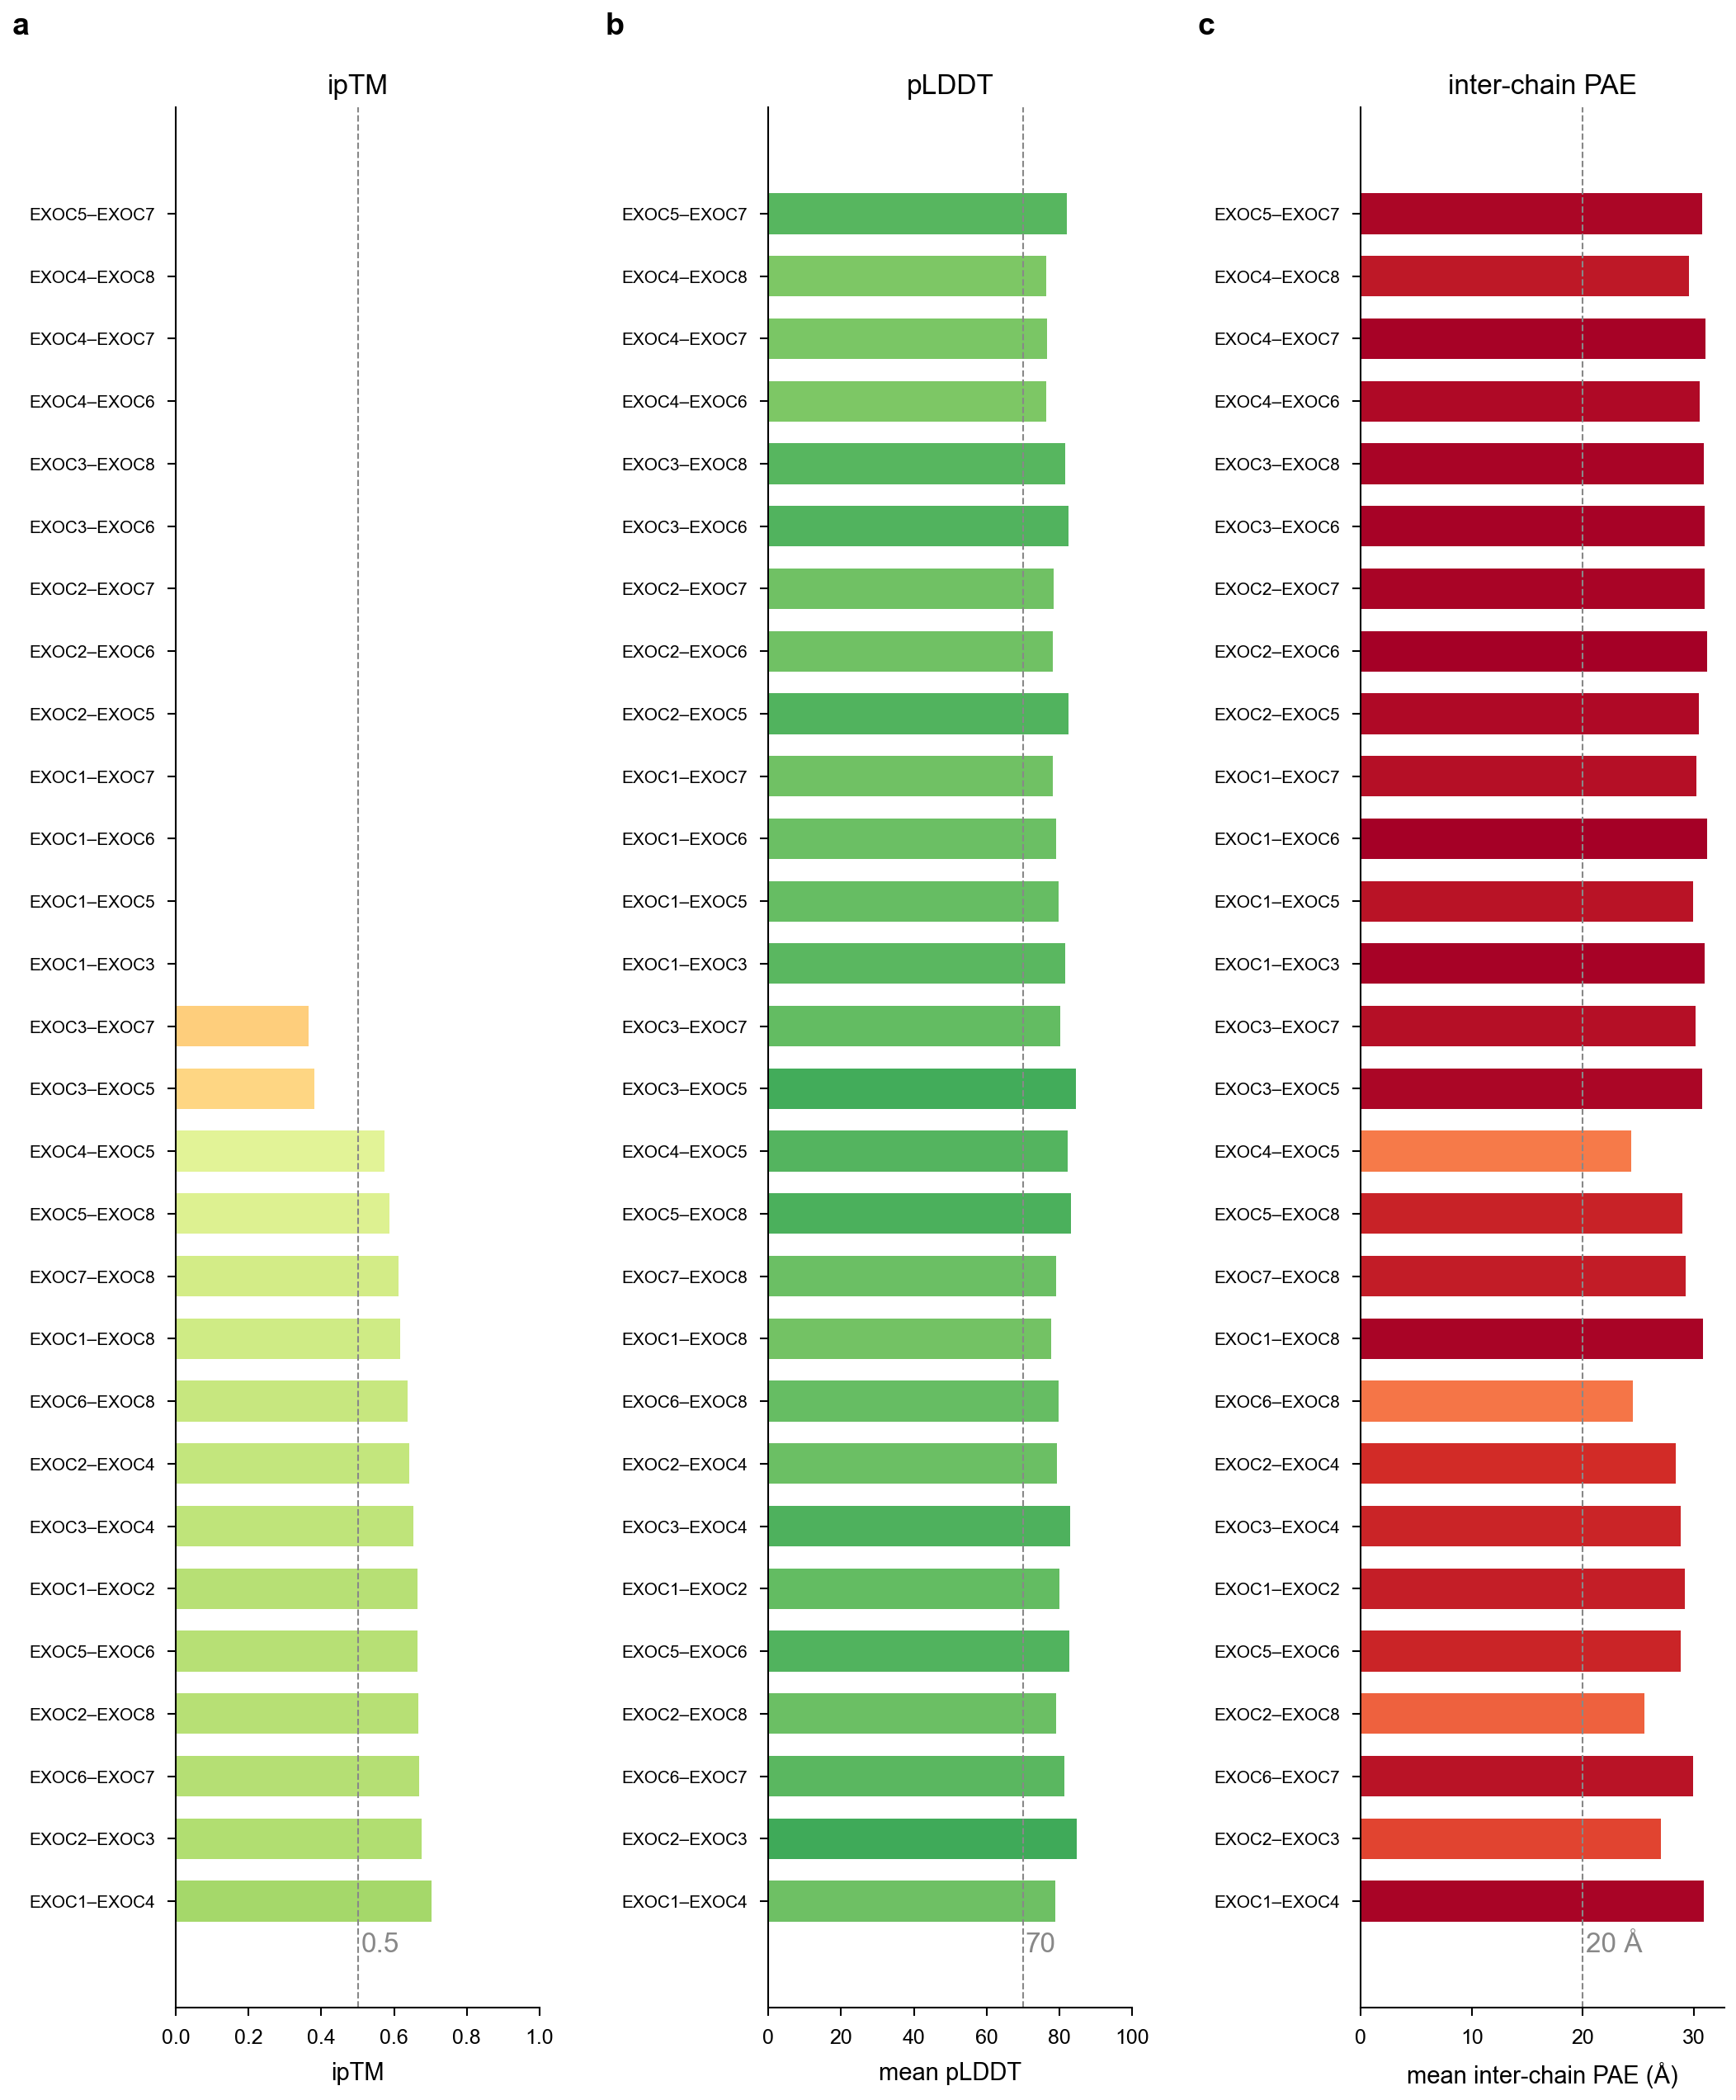

In [30]:
# ── Figure 1: Pair metrics summary ───────────────────────────────────────────
n = len(summary_df)
row_h = 0.28
h = max(1.8, n * row_h + 0.7)

fig, axes = plt.subplots(1, 3, figsize=(NC2, h))
y = np.arange(n)

# y-axis labels: gene names joined by en-dash
gene_labels = summary_df["genes"].values

# ── a: ipTM ──
ax = axes[0]
iptm_vals  = summary_df["iptm"].fillna(0).values
bar_colors = [plt.cm.RdYlGn(v) for v in iptm_vals]
ax.barh(y, iptm_vals, color=bar_colors, height=0.65, linewidth=0)
ax.axvline(0.5, color="#888888", linestyle="--", linewidth=0.5)
ax.text(0.51, -0.5, "0.5", color="#888888", fontsize=8, va="top")
ax.set_xlim(0, 1.0)
ax.set_xlabel("ipTM")
ax.set_yticks(y)
ax.set_yticklabels(gene_labels, fontsize=5)
ax.set_title("ipTM", pad=4)
ax.text(-0.45, 1.05, "a", transform=ax.transAxes,
        fontsize=9, fontweight="bold", va="top")

# ── b: mean pLDDT ──
ax = axes[1]
plddt_vals = summary_df["mean_plddt"].values
bar_colors = [plt.cm.RdYlGn(v / 100) for v in plddt_vals]
ax.barh(y, plddt_vals, color=bar_colors, height=0.65, linewidth=0)
ax.axvline(70, color="#888888", linestyle="--", linewidth=0.5)
ax.text(70.5, -0.5, "70", color="#888888", fontsize=8, va="top")
ax.set_xlim(0, 100)
ax.set_xlabel("mean pLDDT")
ax.set_yticks(y)
ax.set_yticklabels(gene_labels, fontsize=5)
ax.set_title("pLDDT", pad=4)
ax.text(-0.45, 1.05, "b", transform=ax.transAxes,
        fontsize=9, fontweight="bold", va="top")

# ── c: mean inter-chain PAE ──
ax = axes[2]
pae_vals   = summary_df["mean_inter_pae"].values
max_pae    = np.nanmax(pae_vals) if not np.all(np.isnan(pae_vals)) else 30
bar_colors = [plt.cm.RdYlGn_r(v / max_pae) for v in pae_vals]
ax.barh(y, pae_vals, color=bar_colors, height=0.65, linewidth=0)
ax.axvline(20, color="#888888", linestyle="--", linewidth=0.5)
ax.text(20.3, -0.5, "20 Å", color="#888888", fontsize=8, va="top")
ax.set_xlabel("mean inter-chain PAE (Å)")
ax.set_yticks(y)
ax.set_yticklabels(gene_labels, fontsize=5)
ax.set_title("inter-chain PAE", pad=4)
ax.text(-0.45, 1.05, "c", transform=ax.transAxes,
        fontsize=9, fontweight="bold", va="top")

fig.tight_layout(w_pad=1.2)
save_fig(fig, "pair_metrics_summary")
plt.show()

**Fig. 1 | Predicted structural quality metrics for all 28 exocyst subunit dimer pairs.**
**(a)** Interface TM-score (ipTM) derived from the inter-chain predicted aligned error (PAE) matrix using the TM-score formulation (interface residue-pair criterion: PAE < 12 Å in either direction). Pairs in which no residues satisfy this criterion are displayed as zero. Dashed reference line at ipTM = 0.5.
**(b)** Mean per-residue pLDDT (predicted local distance difference test) extracted from Cα B-factors of the top-ranked AlphaFold model. Dashed reference line at pLDDT = 70.
**(c)** Mean inter-chain PAE (Å) computed by averaging all PAE matrix elements between the two partner chains. Dashed reference line at 20 Å. Pairs are ordered by descending ipTM; pairs lacking a detectable interface (ipTM = NaN) are shown at the bottom. In panels **(a)** and **(b)** the bar colour follows a red–yellow–green gradient (low to high confidence); in **(c)** the gradient is reversed so that green encodes low error (high confidence).


In [ ]:
# ── Figure 2: PAE heatmaps (square panels, gene names as axis labels) ────────
n_pairs = len(pairs_data)
ncols   = min(4, n_pairs)
nrows   = (n_pairs + ncols - 1) // ncols
panel_w = NC2 / ncols

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(NC2, panel_w * nrows),
    squeeze=False,
    constrained_layout=True,
)

for idx, (pair_name, d) in enumerate(sorted(pairs_data.items())):
    row, col = divmod(idx, ncols)
    ax  = axes[row][col]
    pae = d["pae"]
    tc  = d["token_chains"]
    N   = len(tc)

    im = ax.imshow(pae, cmap="RdYlGn_r", vmin=0, vmax=30,
                   aspect="equal", interpolation="nearest", rasterized=True)

    # Chain boundary lines
    boundaries = [0]
    for i in range(1, N):
        if tc[i] != tc[i - 1]:
            boundaries.append(i)
    boundaries.append(N)

    for b in boundaries[1:-1]:
        ax.axhline(b - 0.5, color="k", linewidth=0.4)
        ax.axvline(b - 0.5, color="k", linewidth=0.4)

    # Gene-name labels: rotated 45° on x-axis, horizontal on y-axis
    unique_tc = list(dict.fromkeys(tc))
    offset = N * 0.04
    for k, c in enumerate(unique_tc):
        mid      = (boundaries[k] + boundaries[k + 1]) / 2
        genename = chain_gene.get(c, c)
        ax.text(mid, -offset, genename,
                ha="center", va="center", fontsize=5,
                rotation=0, clip_on=False)
        ax.text(-offset, mid, genename,
                ha="center", va="center", fontsize=5, 
                rotation=90, clip_on=False)

    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(0.4)

    # Pair label (gene names) + ipTM below the image
    iptm_str = f"{d['iptm']:.3f}" if not np.isnan(d["iptm"]) else "n/a"
    ax.set_xlabel(
        f"{pair_label(pair_name, chain_gene)}  ipTM = {iptm_str}",
        labelpad=4
    )

    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02, shrink=0.90)
    cb.set_label("PAE (Å)", labelpad=2)
    cb.ax.tick_params(labelsize=5, width=0.4, length=2)
    cb.outline.set_linewidth(0.4)

    ax.text(-0.1, 1.04, _panel_label(idx), transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

for idx in range(n_pairs, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Predicted aligned error (PAE) — all dimer pairs", fontsize=8)
save_fig(fig, "pae_heatmaps")
plt.show()

**Fig. 2 | Predicted aligned error (PAE) heatmaps for all 28 exocyst subunit dimer pairs.**
Each panel shows the full N×N PAE matrix (Å) for one AlphaFold dimer prediction. Rows and columns represent residues ordered within each chain; solid lines mark chain boundaries. Gene names labelling the axes identify each chain. The colour scale ranges from 0 (green, low error, high confidence in relative positioning) to 30 Å (red). The ipTM score computed from the interface PAE is reported in each panel subtitle. Panels are labelled **a–ab** in alphabetical order by pair identifier (AB through GH).


In [ ]:
# ── Figure 3: Per-residue mean inter-chain PAE ───────────────────────────────
n_pairs = len(pairs_data)
ncols   = min(3, n_pairs)
nrows   = (n_pairs + ncols - 1) // ncols
panel_h = 1.35

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(NC2, panel_h * nrows + 0.4),
                         squeeze=False)

for idx, (pair_name, d) in enumerate(sorted(pairs_data.items())):
    row, col = divmod(idx, ncols)
    ax  = axes[row][col]
    pae = d["pae"]
    tc  = d["token_chains"]

    unique_tc = sorted(set(tc))
    x_offset  = 0
    cb_pos    = [0]

    for k, c in enumerate(unique_tc):
        mask_c  = tc == c
        inter_c = tc != c
        y_vals  = (pae[mask_c][:, inter_c].mean(axis=1)
                   if inter_c.any()
                   else np.full(mask_c.sum(), np.nan))
        xs = np.arange(x_offset, x_offset + len(y_vals))
        ax.plot(xs, y_vals,
                color=WONG[k % len(WONG)], linewidth=0.65,
                label=chain_gene.get(c, c))          # gene name in legend
        x_offset += len(y_vals)
        cb_pos.append(x_offset)

    for b in cb_pos[1:-1]:
        ax.axvline(b, color="k", linewidth=0.4, alpha=0.4)

    ax.axhline(20, color="#888888", linestyle="--", linewidth=0.5)
    ax.text(x_offset * 0.01, 20.8, "20 Å",
            color="#888888", fontsize=5, va="bottom")

    ax.set_xlim(0, x_offset)
    ax.set_ylim(bottom=0)
    ax.set_title(pair_label(pair_name, chain_gene), pad=3)
    ax.set_ylabel("mean inter-chain\nPAE (Å)" if col == 0 else "")
    ax.set_xlabel("residue index" if row == nrows - 1 else "")
    ax.legend(loc="upper right", handlelength=1.2, handletextpad=0.4)

    ax.text(-0.14, 1.07, _panel_label(idx), transform=ax.transAxes,
            fontsize=9, fontweight="bold", va="top")

for idx in range(n_pairs, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle("Per-residue mean inter-chain PAE — all dimer pairs",
             y=1.01, fontsize=8)
fig.tight_layout(h_pad=1.2, w_pad=0.8)
save_fig(fig, "inter_chain_pae_per_residue")
plt.show()

**Fig. 3 | Per-residue mean inter-chain PAE for all 28 exocyst subunit dimer pairs.**
For each residue *i*, the mean PAE to all residues belonging to the partner chain is plotted as a function of residue index. Within each panel the two polypeptide chains are colour-coded (blue: first subunit; orange: second subunit) and separated by a vertical dashed line. A horizontal grey dashed line marks the 20 Å reference threshold; residues with mean inter-chain PAE below this line contribute most to interface confidence. Panel titles show the gene-pair name. The y-axis label is shown only on the leftmost panel of each row for clarity.


In [33]:
# ── Export to CSV ─────────────────────────────────────────────────────────────

out_dir = pairdir.parent / "metrics"
out_dir.mkdir(parents=True, exist_ok=True)

summary_csv = out_dir / "pair_summary.csv"
residue_csv = out_dir / "pair_per_residue.csv"

summary_df.to_csv(summary_csv, index=False)
residue_df.to_csv(residue_csv, index=False)

print(f"Saved summary     → {summary_csv}")
print(f"Saved per-residue → {residue_csv}")
print(f"Saved SVG figures → {FIGURE_DIR}")
print()
print(summary_df.to_string(index=False))

Saved summary     → N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex\metrics\pair_summary.csv
Saved per-residue → N:\08_NK_structure_prediction\data\Exocyst_complex\assembled_complex\metrics\pair_per_residue.csv
Saved SVG figures → N:\08_NK_structure_prediction\XL_MOPLC\XL_complex_structure\result\metrics_figures

pair       genes chains  n_residues   iptm  mean_plddt  mean_inter_pae
  AD EXOC1–EXOC4    A,D        1868 0.7026       78.89           30.93
  BC EXOC2–EXOC3    B,C        1669 0.6767       84.86           27.02
  FG EXOC6–EXOC7    F,G        1539 0.6687       81.30           29.96
  BH EXOC2–EXOC8    B,H        1649 0.6668       79.03           25.53
  EF EXOC5–EXOC6    E,F        1512 0.6655       82.77           28.81
  AB EXOC1–EXOC2    A,B        1818 0.6648       80.14           29.17
  CD EXOC3–EXOC4    C,D        1719 0.6522       82.97           28.83
  BD EXOC2–EXOC4    B,D        1898 0.6423       79.29           28.33
  FH EXOC6–EXOC8    F,H  